# New demand actors: EOM and aFRR price impact

This notebook measures the day-ahead (EOM) and aFRR (`CRM_energy_neg`) price impact
of four new demand categories added on top of the base German/European scenario:
steel plants, cement plants, and aviation/maritime E-fuel demand (see the
methodology note below for why aviation and maritime end up as one category here).

It compares each with-actors scenario against the matching no-actor baseline,
same family/year/hour, across the 16 case folders (8 price-taker + 8 `_BID` twins)
x 6 families x 4 years = up to 384 scenarios.

**The batch producing the with-actors data was still running at the time this
notebook was written** (26/384 scenarios finished, one case complete). Every
number and chart below is computed from whatever has finished by the time you
run the cell — re-run the notebook top to bottom at any point to pick up more
scenarios as the batch progresses; already-processed scenarios are cached under
`examples/outputs/_analysis_cache/` so a re-run only does work for what's new.

In [1]:
from pathlib import Path
import sys

notebook_dir = Path.cwd() if (Path.cwd() / "actor_impact_utils.py").exists() else Path.cwd() / "examples" / "notebooks"
sys.path.insert(0, str(notebook_dir))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import actor_impact_utils as aiu

plt.rcParams.update(
    {
        "figure.dpi": 130,
        "savefig.dpi": 200,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.6,
    }
)

# Okabe-Ito colorblind-safe qualitative palette, fixed assignment per category.
COLOR = {
    "steel": "#0072B2",
    "cement": "#E69F00",
    "aviation_maritime": "#009E73",
    "combined": "#D55E00",
    "actor": "#0072B2",
    "baseline": "#7F7F7F",
}
CATEGORY_LABEL = {
    "steel": "Steel",
    "cement": "Cement",
    "aviation_maritime": "Aviation + Maritime",
}
CATEGORIES = aiu.CATEGORIES

# Fixed per-case colors (Okabe-Ito CVD-safe set + two neutrals), same order as
# aiu.PRICE_TAKER_CASES, assigned once and reused everywhere a case is plotted.
CASE_COLOR = dict(
    zip(
        aiu.PRICE_TAKER_CASES,
        ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#56B4E9", "#000000", "#999999"],
    )
)
SOURCE_COLOR = {"Wind Offshore": "#08306B", "Wind Onshore": "#4292C6", "Solar PV": "#E1AD01"}

## 1. What's actually in `examples/outputs/` right now

Before analysing anything, check what's really finished — the batch is
non-deterministic in scenario order and may still be mid-run.

In [2]:
archives = aiu.discover_archives()

coverage = (
    archives.assign(n=1)
    .pivot_table(index="case", columns="family", values="n", aggfunc="sum", fill_value=0)
    .reindex(columns=aiu.FAMILIES, fill_value=0)
    .reindex(index=aiu.ALL_CASES, fill_value=0)
)
coverage["total"] = coverage.sum(axis=1)
coverage.loc["TOTAL"] = coverage.sum(axis=0)

print(f"{len(archives)}/384 with-actor scenarios finished "
      f"({len(archives) / 384:.0%}) as of this run.")
print(f"Cases with at least one finished scenario: {sorted(archives['case'].unique())}")
coverage

53/384 with-actor scenarios finished (14%) as of this run.
Cases with at least one finished scenario: ['AktuellePolitiken_RN', 'FokusH2_RN', 'FokusStrom_RN']


family,aktuellepolitiken,fokusH2,fokusstrom,hohenachfrage,niedrigenachfrage,technologiemix,total
case,,,,,,,
AktuellePolitiken_RN,4,2,4,4,4,4,22
FokusH2_RN,4,4,4,4,4,4,24
FokusStrom_RN,4,2,1,0,0,0,7
HoheNachfrage_RN,0,0,0,0,0,0,0
NachfrageNiedrig_RN,0,0,0,0,0,0,0
Technologiemix_RN,0,0,0,0,0,0,0
WCMean,0,0,0,0,0,0,0
WCTail,0,0,0,0,0,0,0
AktuellePolitiken_RN_BID,0,0,0,0,0,0,0


In [3]:
# Cross-check against the live batch log, if present.
log = Path("../outputs/full_batch.log")
if log.exists():
    lines = log.read_text().splitlines()
    done = sum(1 for l in lines if l.strip().startswith("[") and "/384]" in l.split()[0])
    ok = sum(1 for l in lines if "/384]" in l.split(maxsplit=1)[0] and " OK" in l)
    print(f"full_batch.log: {done}/384 log entries, {ok} OK. Last 5 lines:")
    for l in lines[-5:]:
        print(" ", l)
else:
    print("No full_batch.log found next to this notebook's ../outputs — skipping log cross-check.")

full_batch.log: 53/384 log entries, 53 OK. Last 5 lines:
  [49/384] OK      FokusStrom_RN/aktuellepolitiken_2030           301.4min  compressed 359.2 MB
  [50/384] OK      FokusStrom_RN/aktuellepolitiken_2045           268.0min  compressed 270.6 MB
  [51/384] OK      FokusStrom_RN/fokusH2_2045                     228.2min  compressed 260.5 MB
  [52/384] OK      FokusStrom_RN/fokusH2_2030                     359.4min  compressed 338.6 MB
  [53/384] OK      FokusStrom_RN/fokusstrom_2040                  222.7min  compressed 280.2 MB


## 2. Methodology notes — verified against the actual data, not assumed

A few things in the data don't quite match a naive reading of the scenario
description, so they're recorded here rather than silently worked around:

- **Aviation and maritime are not separable actor categories in this data.**
  `demand_units.csv` labels every aviation/maritime demand unit with
  `technology = "aviation_maritime avmar_da"` / `"avmar_afrr"` and unit_id
  `demand_AVMAR_{DA,aFRR}_<node>` — one aggregated series per grid node (30 of
  the network's 44 nodes carry AVMAR demand), with no per-facility or
  per-mode (aviation vs. maritime) breakdown anywhere in the scenario inputs
  or outputs. So below, "Aviation + Maritime" is reported as a single combined
  category, not two.
- **Steel and cement *are* separable** by unit_id prefix
  (`demand_P100000120*` = steel, `demand_P10000012{4,5}*` = cement), confirmed
  against `demand_units.csv`'s `technology` column.
- **No literal warm-up day was found in any output file.** Every scenario's
  `config.yaml` sets `start_date: <year-1>-12-31`, but both the baseline and
  the with-actor `market_meta.csv`/`market_orders.csv` start at `<year>-01-01`
  in practice — the warm-up hours are apparently never written to the output
  tables. The `time >= Jan 1` filter is kept anyway as a defensive no-op, in
  case some scenario combination turns out to behave differently.
- **Per-category price impact is a joint-run attribution, not a causal
  decomposition.** All four actor categories bid into the same simulation
  alongside each other; there is no steel-only / cement-only / AVMAR-only run
  to isolate one category's effect on price in the way an ablation would
  (`steel_base`/`cement_base` under `examples/inputs/` turned out to be the
  *pure no-actor* baseline generation inputs, not per-category ablations —
  confirmed via `demand_units.csv`, which contains zero steel/cement/AVMAR
  rows in either). Section 4's per-category numbers describe *how much of the
  combined price effect coincides with each category's own volume/curtailment*,
  not "what price would look like with only steel added."
- **No `_BID` scenario has finished yet** (batch runs the 8 non-`_BID` cases
  first). Section 5 (served vs. curtailed demand) will show placeholders until
  some exist — re-run later once `_BID` archives appear.

## 3. Overall day-ahead (EOM) and aFRR (CRM_energy_neg) price impact

For every finished with-actor scenario, each hourly EOM / `CRM_energy_neg`
clearing price is matched to the same hour in the matching no-actor baseline
(same family + year), and `delta = price_with_actors - price_baseline` is
computed directly (no aggregation across timestamps beforehand).

In [4]:
price_panel = aiu.build_price_panel(archives)
print(f"{len(price_panel):,} matched hourly price rows across "
      f"{price_panel[['case','family','year']].drop_duplicates().shape[0]} scenarios.")
price_panel.head()

926,016 matched hourly price rows across 53 scenarios.


,market_id,price_actor,time,price_baseline,case,family,year,is_bid,delta
0,EOM,10.016,2030-01-01 00:00:00,10.016,AktuellePolitiken_RN,aktuellepolitiken,2030,False,0.000
1,EOM,10.016,2030-01-01 01:00:00,0.000,AktuellePolitiken_RN,aktuellepolitiken,2030,False,10.016
2,EOM,10.016,2030-01-01 02:00:00,10.016,AktuellePolitiken_RN,aktuellepolitiken,2030,False,0.000
3,EOM,10.016,2030-01-01 03:00:00,0.000,AktuellePolitiken_RN,aktuellepolitiken,2030,False,10.016
4,EOM,10.016,2030-01-01 04:00:00,0.000,AktuellePolitiken_RN,aktuellepolitiken,2030,False,10.016


In [5]:
summary = (
    price_panel.groupby("market_id")["delta"]
    .agg(mean="mean", median="median", std="std", p05=lambda s: s.quantile(0.05),
         p95=lambda s: s.quantile(0.95), max="max", min="min")
    .round(2)
)
summary

,mean,median,std,p05,p95,max,min
market_id,,,,,,,
CRM_energy_neg,0.01,0.0,1.38,0.0,0.0,230.64,-0.02
EOM,22.33,0.0,89.40,0.0,165.8,3000.00,-3000.00


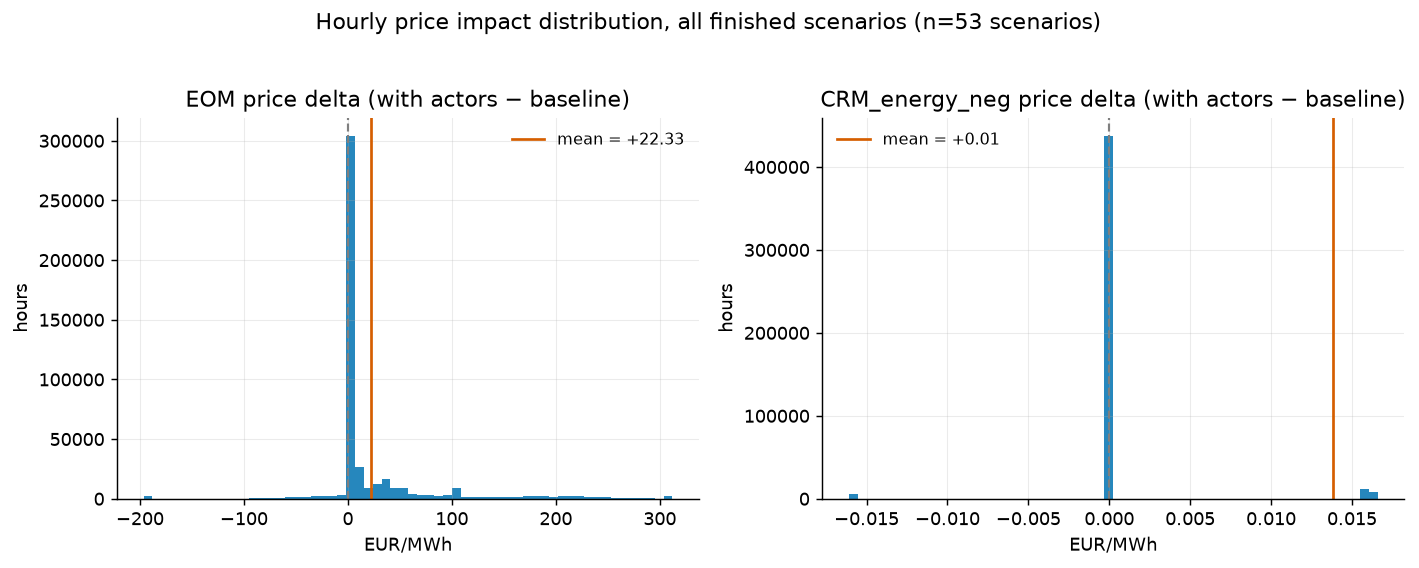

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=False)
for ax, market in zip(axes, ["EOM", "CRM_energy_neg"]):
    d = price_panel.loc[price_panel["market_id"] == market, "delta"]
    ax.hist(d.clip(d.quantile(0.005), d.quantile(0.995)), bins=60,
            color=COLOR["actor"], alpha=0.85)
    ax.axvline(0, color=COLOR["baseline"], linewidth=1.2, linestyle="--")
    ax.axvline(d.mean(), color=COLOR["combined"], linewidth=1.5,
                label=f"mean = {d.mean():+.2f}")
    ax.set_title(f"{market} price delta (with actors − baseline)")
    ax.set_xlabel("EUR/MWh" if market == "EOM" else "EUR/MWh")
    ax.set_ylabel("hours")
    ax.legend(frameon=False, fontsize=9)
fig.suptitle("Hourly price impact distribution, all finished scenarios "
             f"(n={price_panel[['case','family','year']].drop_duplicates().shape[0]} scenarios)",
             y=1.03)
fig.tight_layout()
plt.show()

In [7]:
by_year = (
    price_panel.groupby(["market_id", "year"])["delta"]
    .agg(mean="mean", median="median", p95=lambda s: s.quantile(0.95))
    .round(2)
    .unstack("market_id")
)
by_year

mean                median                  p95        
market_id CRM_energy_neg    EOM CRM_energy_neg   EOM CRM_energy_neg     EOM
year                                                                       
2030                0.03  19.85            0.0  4.24           0.00  103.93
2035                0.02  18.93            0.0  0.00           0.00  194.69
2040                0.00  22.66            0.0  0.00           0.00  191.63
2045                0.01  27.42            0.0  0.00           0.02  187.70

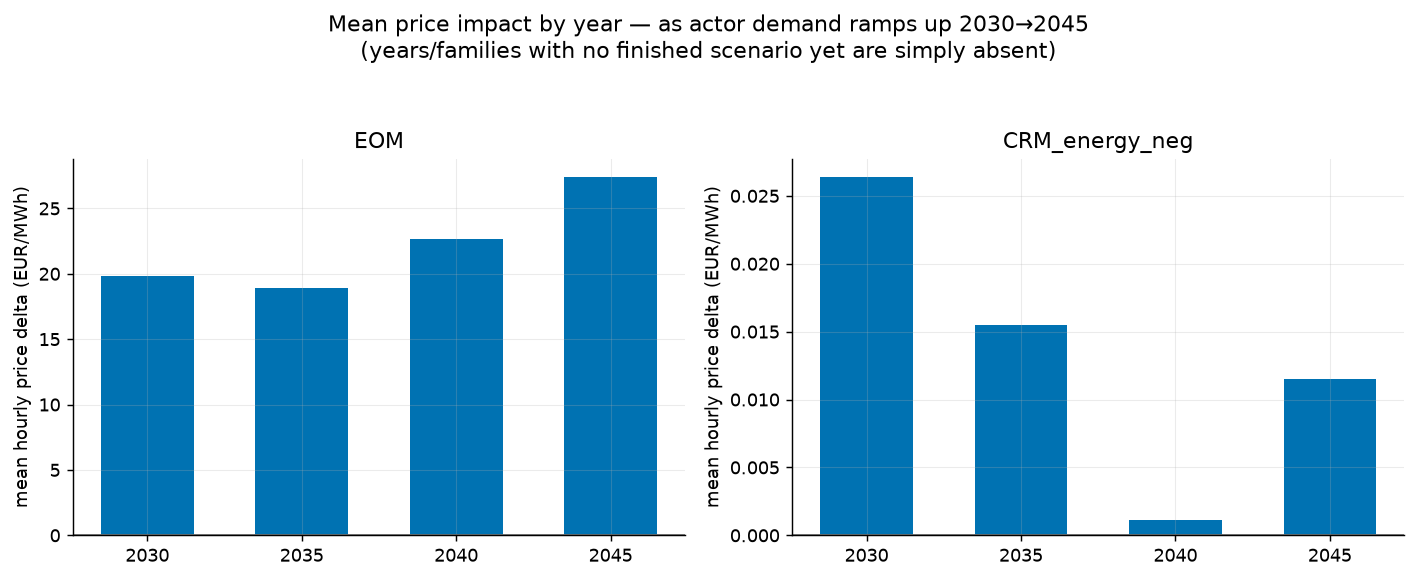

Scenario coverage behind this chart, by year:
year
2030    14
2035    12
2040    13
2045    14
dtype: int64


In [8]:
# EOM and CRM_energy_neg deltas are ~1000x apart in magnitude (EUR/MWh vs.
# fractions of a cent) -- one shared axis would make CRM_energy_neg invisible,
# so this is two independently-scaled panels rather than one dual-axis chart.
piv = price_panel.groupby(["year", "market_id"])["delta"].mean().unstack("market_id")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, market in zip(axes, ["EOM", "CRM_energy_neg"]):
    vals = piv.get(market, pd.Series(index=piv.index, dtype=float))
    ax.bar(piv.index.astype(str), vals, color=COLOR["actor"], width=0.6)
    ax.axhline(0, color=COLOR["baseline"], linewidth=1)
    ax.set_ylabel("mean hourly price delta (EUR/MWh)")
    ax.set_title(market)
fig.suptitle("Mean price impact by year — as actor demand ramps up 2030→2045\n"
             "(years/families with no finished scenario yet are simply absent)", y=1.05)
fig.tight_layout()
plt.show()

print("Scenario coverage behind this chart, by year:")
print(archives.groupby("year").size().reindex(aiu.YEARS, fill_value=0))

## 4. Per-actor-category contribution

`market_orders.csv` is streamed and filtered (chunked, `usecols`-limited — the
raw file is several GB per scenario) down to just the three actor categories'
own bids, aggregated to one row per (scenario, hour, market, category). This
gives cleared volume per category, which is compared against the *system-wide*
price delta from Section 3 as a proxy for each category's share of the impact
— see the Section 2 caveat: this is an attribution over a joint run, not an
ablation.

In [9]:
orders_panel = aiu.build_orders_panel(archives)
print(f"{len(orders_panel):,} (scenario, hour, market, category) rows.")
orders_panel.head()

2,000,685 (scenario, hour, market, category) rows.


,start_time,market_id,category,volume,accepted_volume,case,family,year,is_bid
0,2030-01-01 00:00:00,CRM_energy_neg,aviation_maritime,-17.201331,-17.201331,AktuellePolitiken_RN,aktuellepolitiken,2030,False
1,2030-01-01 00:00:00,CRM_energy_neg,steel,-664.000000,-664.000000,AktuellePolitiken_RN,aktuellepolitiken,2030,False
2,2030-01-01 00:00:00,EOM,cement,-10468.172700,-10468.172700,AktuellePolitiken_RN,aktuellepolitiken,2030,False
3,2030-01-01 00:00:00,EOM,steel,-3.846550,-3.846550,AktuellePolitiken_RN,aktuellepolitiken,2030,False
4,2030-01-01 01:00:00,CRM_energy_neg,steel,-664.000000,-664.000000,AktuellePolitiken_RN,aktuellepolitiken,2030,False


In [10]:
vol_summary = (
    orders_panel.groupby(["market_id", "category"])[["volume", "accepted_volume"]]
    .sum()
    .abs()  # demand volumes are signed negative in market_orders.csv
    .rename(columns={"volume": "bid_MWh", "accepted_volume": "cleared_MWh"})
)
vol_summary["cleared_share"] = (vol_summary["cleared_MWh"] / vol_summary["bid_MWh"]).round(4)
vol_summary.round(1)

bid_MWh   cleared_MWh  cleared_share
market_id      category                                                    
CRM_energy_neg aviation_maritime  3.250776e+07  3.250776e+07            1.0
               cement             3.106416e+08  3.106290e+08            1.0
               steel              1.406457e+08  1.406412e+08            1.0
EOM            aviation_maritime  5.138520e+07  5.138520e+07            1.0
               cement             3.828420e+09  3.828420e+09            1.0
               steel              1.703578e+09  1.703578e+09            1.0

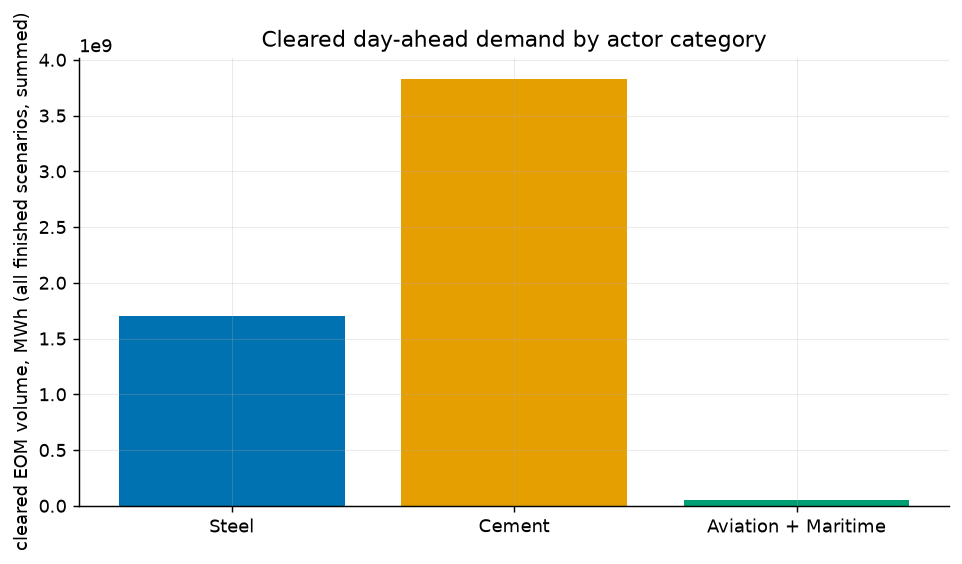

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
share = (
    orders_panel[orders_panel["market_id"] == "EOM"]
    .groupby("category")["accepted_volume"].sum().abs()
)
share = share.reindex(CATEGORIES)
ax.bar([CATEGORY_LABEL[c] for c in share.index], share.values,
       color=[COLOR[c] for c in share.index])
ax.set_ylabel("cleared EOM volume, MWh (all finished scenarios, summed)")
ax.set_title("Cleared day-ahead demand by actor category")
fig.tight_layout()
plt.show()

In [12]:
# Hour-by-hour: does the system price delta track total actor demand?
hourly_price = (
    price_panel[price_panel["market_id"] == "EOM"]
    .groupby(["case", "family", "year", "time"])["delta"].mean()
)
hourly_actor_vol = (
    orders_panel[orders_panel["market_id"] == "EOM"]
    .groupby(["case", "family", "year", "start_time", "category"])["accepted_volume"]
    .sum().abs().unstack("category").reindex(columns=CATEGORIES, fill_value=0)
)
hourly_actor_vol.index = hourly_actor_vol.index.set_names("time", level="start_time")

joined = hourly_price.to_frame("price_delta").join(hourly_actor_vol, how="inner")
joined["total_actor_volume"] = joined[CATEGORIES].sum(axis=1)

corr = joined[["price_delta", "total_actor_volume", *CATEGORIES]].corr()["price_delta"].drop("price_delta")
print("Hour-level correlation of EOM price delta with cleared actor volume "
      "(system-wide and per category):")
corr.round(3)

Hour-level correlation of EOM price delta with cleared actor volume (system-wide and per category):


total_actor_volume    0.029
steel                 0.022
cement                0.032
aviation_maritime    -0.006
Name: price_delta, dtype: float64

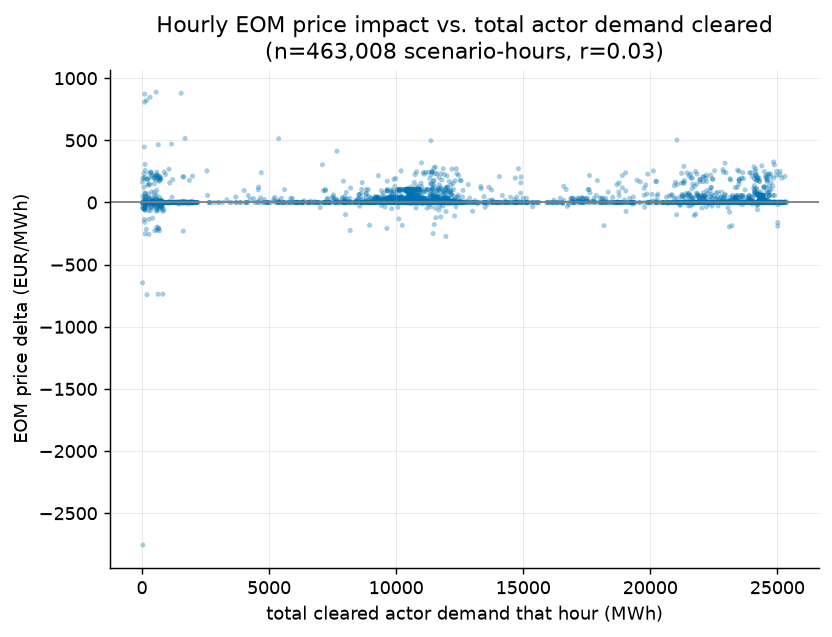

In [13]:
fig, ax = plt.subplots(figsize=(6.5, 5))
sample = joined.sample(min(4000, len(joined)), random_state=0) if len(joined) else joined
ax.scatter(sample["total_actor_volume"], sample["price_delta"],
           s=8, alpha=0.35, color=COLOR["actor"], edgecolors="none")
ax.axhline(0, color=COLOR["baseline"], linewidth=1)
ax.set_xlabel("total cleared actor demand that hour (MWh)")
ax.set_ylabel("EOM price delta (EUR/MWh)")
ax.set_title("Hourly EOM price impact vs. total actor demand cleared\n"
             f"(n={len(joined):,} scenario-hours, r={corr.get('total_actor_volume', float('nan')):.2f})")
fig.tight_layout()
plt.show()

## 5. Served vs. curtailed demand: price-taker vs. `_BID`

Price-taker cases bid at the market cap, so actor demand always clears (100%
by construction) — this is the baseline for "how much this actor category
demands." `_BID` cases bid at the actor's own assumed economics, so they get
curtailed whenever the simulated clearing price exceeds what the plant model
assumed. Comparing served volume between the two treatments shows how much of
each category's own investment-case economics actually survive contact with
the simulated market — directly relevant to interpreting Section 4's price
impact, since a heavily curtailed `_BID` actor mechanically has less price
impact than its full economic model assumed.

In [14]:
bid_archives = archives[archives["is_bid"]]
if bid_archives.empty:
    print("No _BID scenarios have finished yet (the batch runs the 8 non-_BID "
          "cases first) — nothing to compare. Re-run this section once some exist; "
          "the pipeline below is ready to go as soon as they do.")
else:
    bid_orders = aiu.build_orders_panel(bid_archives)
    pt_orders = orders_panel[~orders_panel["case"].isin(aiu.BID_CASES)]

    def served_share(df):
        g = df.groupby("category")[["volume", "accepted_volume"]].sum().abs()
        return (g["accepted_volume"] / g["volume"]).reindex(CATEGORIES)

    comparison = pd.DataFrame({
        "price_taker_served_share": served_share(pt_orders[pt_orders["market_id"] == "EOM"]),
        "bid_served_share": served_share(bid_orders[bid_orders["market_id"] == "EOM"]),
    })
    comparison["curtailment_pp"] = (
        (comparison["price_taker_served_share"] - comparison["bid_served_share"]) * 100
    ).round(1)
    display(comparison.round(3))

    fig, ax = plt.subplots(figsize=(7, 4.2))
    x = np.arange(len(CATEGORIES))
    width = 0.35
    ax.bar(x - width / 2, comparison["price_taker_served_share"] * 100, width=width,
           color=COLOR["actor"], label="price-taker (RN)")
    ax.bar(x + width / 2, comparison["bid_served_share"] * 100, width=width,
           color=COLOR["combined"], label="_BID")
    ax.set_xticks(x)
    ax.set_xticklabels([CATEGORY_LABEL[c] for c in CATEGORIES])
    ax.set_ylabel("% of EOM demand actually cleared")
    ax.set_ylim(0, 105)
    ax.set_title("Served demand: price-taker vs. bid-at-own-economics")
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

No _BID scenarios have finished yet (the batch runs the 8 non-_BID cases first) — nothing to compare. Re-run this section once some exist; the pipeline below is ready to go as soon as they do.


## 6. Quarterly aFRR capacity price by case (`CRM_capacity_pos` / `CRM_capacity_neg`)

A different market from everything above: `CRM_capacity_pos`/`CRM_capacity_neg`
are the daily capacity auctions (6x 4-hour blocks/day, `pay_as_bid`), not the
hourly energy markets Sections 3–5 analyze. **The new actors don't submit bids
into either capacity market** — `demand_units.csv` leaves
`bidding_CRM_capacity_pos`/`bidding_CRM_capacity_neg` blank for every steel,
cement and AVMAR unit.

That turns out *not* to mean the capacity price is unaffected, though (see the
sanity check below): with-actors capacity prices differ substantially from the
baseline's, even though no actor bid is present in either market. The
likely mechanism is indirect — the new EOM/aFRR-energy demand changes which
powerplants get dispatched and what capacity they have left over to offer into
the capacity auction, which feeds through to the `pay_as_bid` clearing price.
That's a real second-order finding worth noting, not a bug in this notebook —
but it does mean this section is *not* a clean "actors vs. no actors" panel;
it's a descriptive view of the capacity market by case, shown here because it
groups the same way as the rest of the notebook (by case, auto-updating as
more scenarios finish).

Two more unit notes vs. a typical real-world reference: our `market_meta.csv`
`price` column is `EUR/MW` per cleared 4-hour product block (`config.yaml`'s
`price_unit`), not `EUR/MW/week`, and "quarter" here means calendar quarter of
the product's delivery hour, averaged across whatever family/year combinations
have finished for each case (not a single fixed scenario).

In [15]:
capacity_panel = aiu.build_capacity_panel(archives)
print(f"{len(capacity_panel):,} matched (case, hour, market) capacity rows.")

print("\nScenarios behind each case's bars (family x year combos finished):")
print(archives[archives['case'].isin(aiu.PRICE_TAKER_CASES)].groupby("case").size()
      .reindex(aiu.PRICE_TAKER_CASES, fill_value=0))

# No actor bid ever appears in these markets -- so any gap here is an indirect
# effect (via dispatch/available capacity), not a direct bidding effect.
gap = (capacity_panel["price_actor"] - capacity_panel["price_baseline"]).abs()
level = capacity_panel[["price_actor", "price_baseline"]].mean().mean()
print(f"\nmean |with-actors − baseline| capacity price gap: {gap.mean():.1f} EUR/MW "
      f"vs. a mean price level of {level:.1f} EUR/MW across both — a "
      f"{gap.mean() / level:.0%} gap despite zero direct actor bids in this market, "
      "i.e. an indirect (dispatch-driven) effect, not noise.")

231,504 matched (case, hour, market) capacity rows.

Scenarios behind each case's bars (family x year combos finished):
case
AktuellePolitiken_RN    22
FokusH2_RN              24
FokusStrom_RN            7
HoheNachfrage_RN         0
NachfrageNiedrig_RN      0
Technologiemix_RN        0
WCMean                   0
WCTail                   0
dtype: int64

mean |with-actors − baseline| capacity price gap: 106.7 EUR/MW vs. a mean price level of 82.6 EUR/MW across both — a 129% gap despite zero direct actor bids in this market, i.e. an indirect (dispatch-driven) effect, not noise.


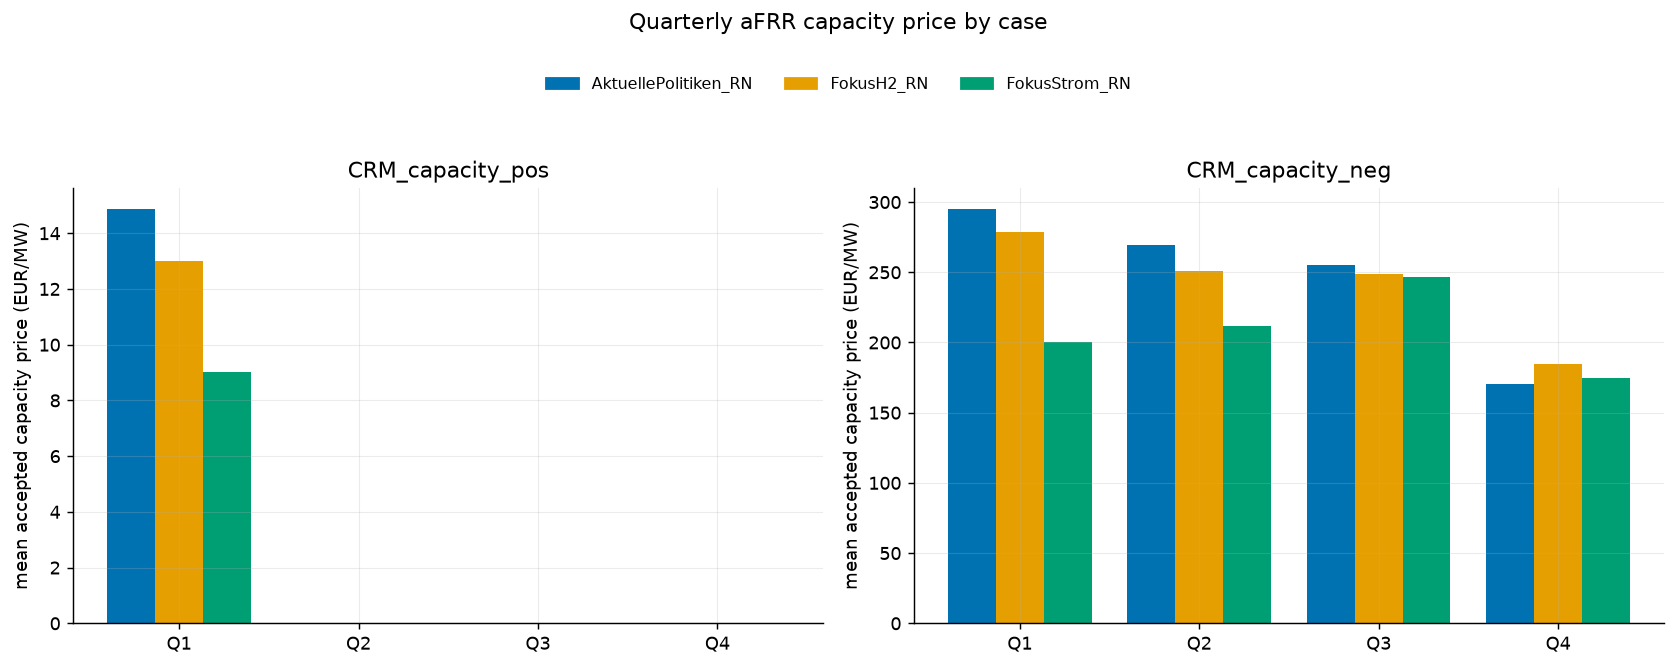

In [16]:
cases_present = [c for c in aiu.PRICE_TAKER_CASES if c in capacity_panel["case"].unique()]
quarters = [1, 2, 3, 4]
x = np.arange(len(quarters))
n = max(len(cases_present), 1)
width = 0.8 / n

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, market in zip(axes, aiu.CAPACITY_MARKETS):
    sub = capacity_panel[capacity_panel["market_id"] == market]
    piv = sub.groupby(["quarter", "case"])["price_actor"].mean().unstack("case").reindex(quarters)
    for i, case in enumerate(cases_present):
        vals = piv[case] if case in piv.columns else pd.Series(np.nan, index=quarters)
        ax.bar(x + (i - (n - 1) / 2) * width, vals, width=width, color=CASE_COLOR[case])
    ax.set_xticks(x)
    ax.set_xticklabels([f"Q{q}" for q in quarters])
    ax.set_ylabel("mean accepted capacity price (EUR/MW)")
    ax.set_title(market)

handles = [plt.Rectangle((0, 0), 1, 1, color=CASE_COLOR[c]) for c in cases_present]
fig.suptitle("Quarterly aFRR capacity price by case", y=1.06)
fig.legend(handles, cases_present, loc="upper center", bbox_to_anchor=(0.5, 0.98),
           ncol=4, frameon=False, fontsize=9)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## 7. Quarterly aFRR energy price by case (`CRM_energy_pos` / `CRM_energy_neg`)

Same layout as Section 6, but for the aFRR *energy* markets instead of
capacity. Unlike the capacity pair, **`CRM_energy_neg` is a market the new
actors actually bid into** (down-regulation / demand-increase — this is the
same market Sections 3–5 analyze in detail, just re-cut here by case and
quarter instead of pooled). `CRM_energy_pos`, by contrast, has no actor bids
at all (`demand_units.csv` only ever sets `bidding_CRM_energy_neg` for the new
units, never `bidding_CRM_energy_pos`), so it's the background-only half of
this pair, included for the same side-by-side comparison as Section 6.

926,016 matched (case, hour, market) aFRR-energy rows.


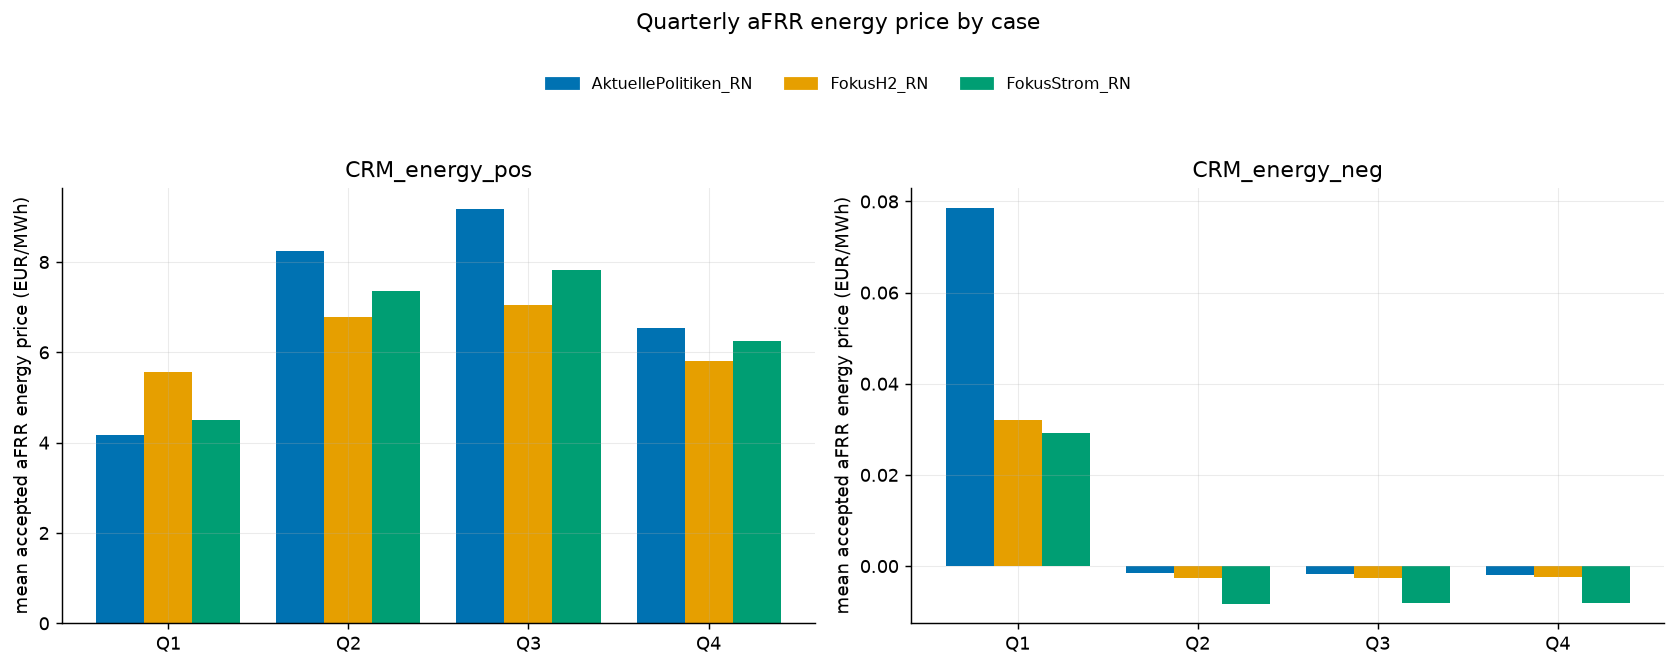

In [17]:
afrr_energy_panel = aiu.build_afrr_energy_panel(archives)
print(f"{len(afrr_energy_panel):,} matched (case, hour, market) aFRR-energy rows.")

cases_present_energy = [c for c in aiu.PRICE_TAKER_CASES if c in afrr_energy_panel["case"].unique()]
n = max(len(cases_present_energy), 1)
width = 0.8 / n

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, market in zip(axes, aiu.AFRR_ENERGY_MARKETS):
    sub = afrr_energy_panel[afrr_energy_panel["market_id"] == market]
    piv = sub.groupby(["quarter", "case"])["price_actor"].mean().unstack("case").reindex(quarters)
    for i, case in enumerate(cases_present_energy):
        vals = piv[case] if case in piv.columns else pd.Series(np.nan, index=quarters)
        ax.bar(x + (i - (n - 1) / 2) * width, vals, width=width, color=CASE_COLOR[case])
    ax.set_xticks(x)
    ax.set_xticklabels([f"Q{q}" for q in quarters])
    ax.set_ylabel("mean accepted aFRR energy price (EUR/MWh)")
    ax.set_title(market)

handles = [plt.Rectangle((0, 0), 1, 1, color=CASE_COLOR[c]) for c in cases_present_energy]
fig.suptitle("Quarterly aFRR energy price by case", y=1.06)
fig.legend(handles, cases_present_energy, loc="upper center", bbox_to_anchor=(0.5, 0.98),
           ncol=4, frameon=False, fontsize=9)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## 8. Quarterly `CRM_energy_neg` volume: system context and each sector's share

Only the negative side — the new actors never bid into `CRM_energy_pos` (see
Section 7), so a "positive" panel here would be a flat 0% line for all three
categories, every quarter, by construction, and isn't shown.

Left: average system-wide accepted volume in `CRM_energy_neg` per quarter
(every participant — powerplants, storage, exchanges, existing demand, and the
new actors — summed on the demand side of each hour's clearing, which by
market balance equals the supply side; this is *not* the two sides added
together, which would double-count the same cleared MWh). Right: each
category's own accepted volume as a share of that system total, same quarters.
Two panels rather than one dual-axis plot (GW bars vs. % lines is too large a
scale mismatch, and the earlier Section 3 histogram/Section 7 chart already
established this notebook's convention of splitting mismatched scales into
side-by-side panels instead).

One striking thing this surfaces: **steel + cement + aviation/maritime
together already account for the large majority of all accepted
`CRM_energy_neg` volume system-wide** in the scenarios finished so far — this
market looks like a fairly thin one that the new actors now dominate, not a
small addition to a large existing pool. Worth double-checking once more
cases/years are in, since it's currently based on only 2 of 8 cases.

In [18]:
share_panel = aiu.build_energy_neg_share_panel(archives)
print(f"{len(share_panel):,} scenario-hours.")

by_quarter = share_panel.groupby("quarter").agg(
    system_mw=("system_accepted_volume", "mean"),
    system_sum=("system_accepted_volume", "sum"),
    **{c: (c, "sum") for c in CATEGORIES},
).reindex(quarters)
for c in CATEGORIES:
    by_quarter[f"{c}_share_pct"] = by_quarter[c] / by_quarter["system_sum"] * 100
by_quarter[["system_mw"] + [f"{c}_share_pct" for c in CATEGORIES]].round(2)

456,783 scenario-hours.


,system_mw,steel_share_pct,cement_share_pct,aviation_maritime_share_pct
quarter,,,,
1,1294.03,26.58,63.84,4.90
2,1288.06,24.26,65.25,5.72
3,995.25,29.71,58.13,8.26
4,852.56,32.81,55.66,7.63


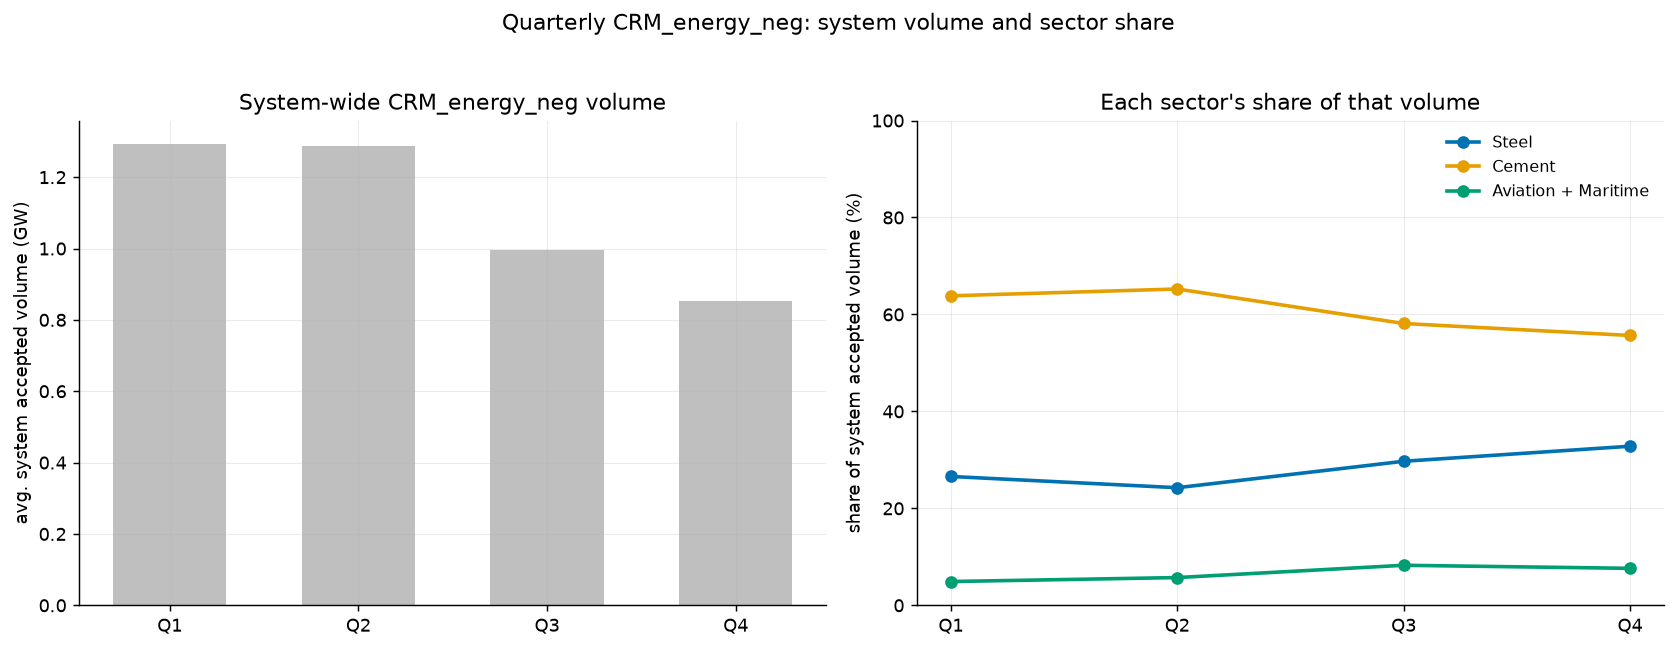

In [19]:
fig, (ax_vol, ax_share) = plt.subplots(1, 2, figsize=(13, 4.8))

ax_vol.bar([f"Q{q}" for q in quarters], by_quarter["system_mw"] / 1000,
           color="#BFBFBF", width=0.6)
ax_vol.set_ylabel("avg. system accepted volume (GW)")
ax_vol.set_title("System-wide CRM_energy_neg volume")

for c in CATEGORIES:
    ax_share.plot([f"Q{q}" for q in quarters], by_quarter[f"{c}_share_pct"],
                  marker="o", color=COLOR[c], label=CATEGORY_LABEL[c], linewidth=2)
ax_share.set_ylabel("share of system accepted volume (%)")
ax_share.set_ylim(0, 100)
ax_share.set_title("Each sector's share of that volume")
ax_share.legend(frameon=False, fontsize=9)

fig.suptitle("Quarterly CRM_energy_neg: system volume and sector share", y=1.03)
fig.tight_layout()
plt.show()

## 9. Combined view: system volume, actor share, and price by case (`CRM_energy_neg`)

Puts Sections 7 and 8 on one chart, in the reference image's original layout:
gray bars are avg. system accepted volume per quarter (Section 8's left panel),
the %-label on each bar is steel + cement + aviation/maritime's **combined**
share of that volume, and the colored lines are each case's mean accepted
`CRM_energy_neg` price per quarter (Section 7's data) plus a black `Mean` line
across cases — same pairing as the reference chart's per-scenario lines. Only
`CRM_energy_neg` is shown, for the same reason as Section 8: the new actors
never bid into `CRM_energy_pos`, so a second panel would just be a flat 0%.

Note this **is** a dual-axis chart (GW bars against a EUR/MWh price line
scale) — Sections 3, 6 and 7 deliberately split mismatched scales into
side-by-side panels instead, but this specific combined layout was asked for
directly, so it's built as asked here rather than substituted.

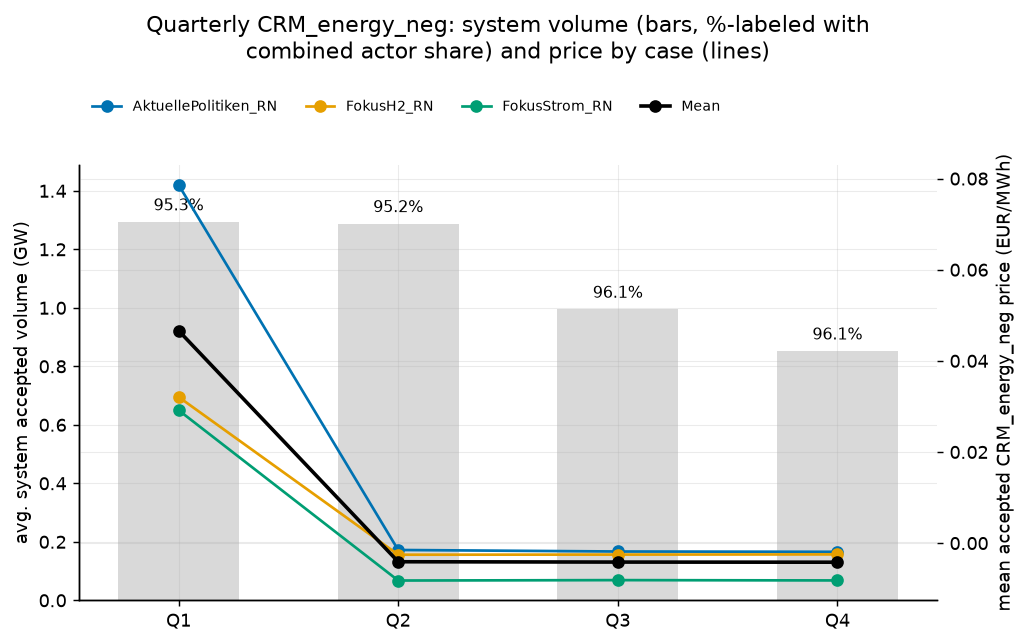

In [20]:
combined = share_panel.groupby("quarter").agg(
    system_mw=("system_accepted_volume", "mean"),
    system_sum=("system_accepted_volume", "sum"),
    **{c: (c, "sum") for c in CATEGORIES},
).reindex(quarters)
combined["actor_share_pct"] = combined[CATEGORIES].sum(axis=1) / combined["system_sum"] * 100

price_by_case = (
    afrr_energy_panel[afrr_energy_panel["market_id"] == "CRM_energy_neg"]
    .groupby(["quarter", "case"])["price_actor"].mean()
    .unstack("case").reindex(quarters)
)
price_by_case["Mean"] = price_by_case[cases_present_energy].mean(axis=1)

fig, ax1 = plt.subplots(figsize=(8, 5.2))
x = np.arange(len(quarters))
bar_vals = combined["system_mw"] / 1000
ax1.bar(x, bar_vals, color="#D9D9D9", width=0.55, zorder=1)
for xi, (val, pct) in enumerate(zip(bar_vals, combined["actor_share_pct"])):
    ax1.text(xi, val + bar_vals.max() * 0.02, f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
ax1.set_ylabel("avg. system accepted volume (GW)")
ax1.set_xticks(x)
ax1.set_xticklabels([f"Q{q}" for q in quarters])
ax1.set_ylim(0, bar_vals.max() * 1.15)

ax2 = ax1.twinx()
for case in cases_present_energy:
    ax2.plot(x, price_by_case[case], marker="o", color=CASE_COLOR[case], linewidth=1.5, label=case)
ax2.plot(x, price_by_case["Mean"], marker="o", color="black", linewidth=2, label="Mean")
ax2.set_ylabel("mean accepted CRM_energy_neg price (EUR/MWh)")

ax2.legend(loc="upper left", bbox_to_anchor=(0, 1.18), ncol=4, frameon=False, fontsize=8)
ax1.set_title("Quarterly CRM_energy_neg: system volume (bars, %-labeled with\n"
              "combined actor share) and price by case (lines)", y=1.22)
fig.tight_layout()
plt.show()

## 10. Redispatch volume/cost and renewable curtailment by case

A system-level view rather than an actor-specific one: `market_id == "redispatch"`
in `market_orders.csv` covers every unit (not just steel/cement/aviation), and
renewable curtailment here means wind/solar units whose output was cut downward
via redispatch for grid congestion — identified by cross-referencing each
scenario's own `powerplant_units.csv` (`technology` in `solar`, `onshore wind`,
`offshore wind AC/DC`) against `unit_id` in the redispatch rows.

Same balance check as `CRM_energy_neg` (Section 8): upward and downward
redispatch instructions balance system-wide per hour (every MW dispatched up
somewhere is matched by an equal MW dispatched down elsewhere), so
**redispatch volume and its cost are computed from the upward side only** —
summing both sides would double-count the same congestion-relief action.
Curtailment doesn't need this adjustment; it's inherently one-sided (only the
downward cut matters).

Each case's bars/lines average over whatever family/year scenarios have
finished for it so far (not a single fixed year) — same convention as
Sections 6, 7 and 9.

In [21]:
redispatch_panel = aiu.build_redispatch_panel(archives)
print(f"{len(redispatch_panel):,} scenarios with a redispatch summary.")

case_summary = (
    redispatch_panel.groupby("case")[
        ["redispatch_volume_twh", "avg_redispatch_cost"] + [f"{t}_curtailment_twh" for t in aiu.CURTAILMENT_SOURCES]
    ]
    .mean()
    .reindex(aiu.PRICE_TAKER_CASES)
    .dropna(how="all")
)
case_summary.round(2)

53 scenarios with a redispatch summary.


,redispatch_volume_twh,avg_redispatch_cost,Wind Offshore_curtailment_twh,Wind Onshore_curtailment_twh,Solar PV_curtailment_twh
case,,,,,
AktuellePolitiken_RN,89.57,2.95,12.88,23.32,33.98
FokusH2_RN,97.22,5.51,13.71,24.10,35.35
FokusStrom_RN,71.06,3.67,10.48,16.17,28.78


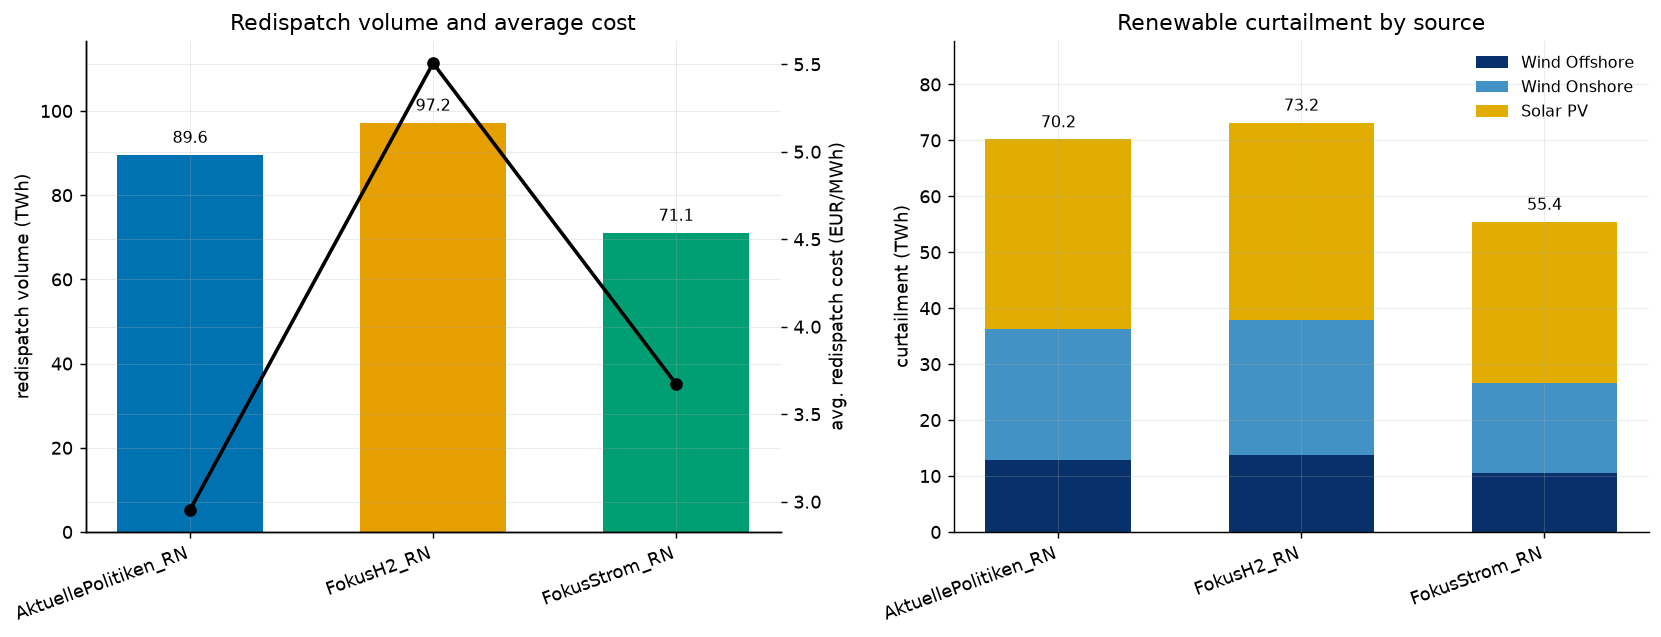

In [22]:
cases_rd = list(case_summary.index)
x = np.arange(len(cases_rd))

fig, (ax_rd, ax_ct) = plt.subplots(1, 2, figsize=(13, 5))

bars = ax_rd.bar(x, case_summary["redispatch_volume_twh"],
                  color=[CASE_COLOR[c] for c in cases_rd], width=0.6)
for xi, val in zip(x, case_summary["redispatch_volume_twh"]):
    ax_rd.text(xi, val + case_summary["redispatch_volume_twh"].max() * 0.02, f"{val:.1f}",
               ha="center", va="bottom", fontsize=9)
ax_rd.set_ylabel("redispatch volume (TWh)")
ax_rd.set_xticks(x)
ax_rd.set_xticklabels(cases_rd, rotation=20, ha="right")
ax_rd.set_ylim(0, case_summary["redispatch_volume_twh"].max() * 1.2)

ax_rd2 = ax_rd.twinx()
ax_rd2.plot(x, case_summary["avg_redispatch_cost"], marker="o", color="black", linewidth=2)
ax_rd2.set_ylabel("avg. redispatch cost (EUR/MWh)")
ax_rd.set_title("Redispatch volume and average cost")

bottom = np.zeros(len(cases_rd))
for src in aiu.CURTAILMENT_SOURCES:
    vals = case_summary[f"{src}_curtailment_twh"].values
    ax_ct.bar(x, vals, bottom=bottom, color=SOURCE_COLOR[src], label=src, width=0.6)
    bottom += vals
for xi, val in zip(x, bottom):
    ax_ct.text(xi, val + bottom.max() * 0.02, f"{val:.1f}", ha="center", va="bottom", fontsize=9)
ax_ct.set_ylabel("curtailment (TWh)")
ax_ct.set_xticks(x)
ax_ct.set_xticklabels(cases_rd, rotation=20, ha="right")
ax_ct.set_ylim(0, bottom.max() * 1.2)
ax_ct.set_title("Renewable curtailment by source")
ax_ct.legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

## 11. Re-running as the batch completes

Everything above re-derives itself from `aiu.discover_archives()` on each run.
Cached per-scenario extractions live under `examples/outputs/_analysis_cache/`
(`baseline_meta/`, `actor_meta/<case>/`, `actor_orders_agg/<case>/`,
`baseline_capacity/`, `actor_capacity_meta/<case>/`, `baseline_afrr_energy/`,
`actor_afrr_energy_meta/<case>/`, `system_energy_neg_volume/<case>/`,
`redispatch_summary/<case>/`) — a plain
re-run of this notebook only pays extraction cost for scenarios that weren't
there last time; everything already cached loads instantly. Nothing needs to
be deleted or invalidated as long as archive contents don't change after being
written (the batch script never overwrites a finished archive).

Once all 384 scenarios (or at least a full family/year/case matrix) are done,
it's worth extending Section 3 with a family-level breakdown (`aktuellepolitiken`
vs `fokusH2` vs ... — RN cases only vary demand by year within a case, so the
family axis there is purely about the *background* system, not actor demand;
WCMean/WCTail's demand does vary by family, so they're the more interesting
axis for that comparison) and Section 5 once `_BID` archives exist across all
8 families.